c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



🔹 SVR for Conductivity
✅ R² Score: 0.9706
✅ RMSE: 0.0455
✅ MAE: 0.0360 
✅ MAPE: 0.06% 


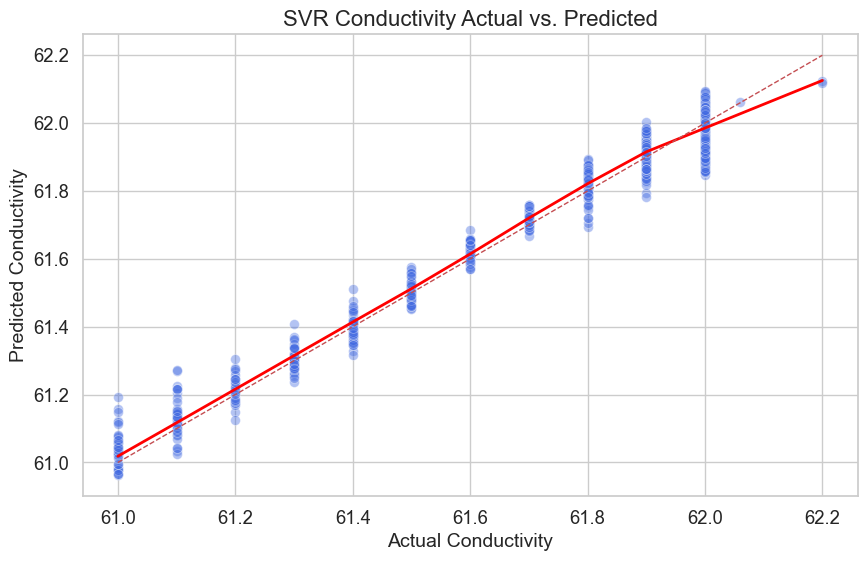

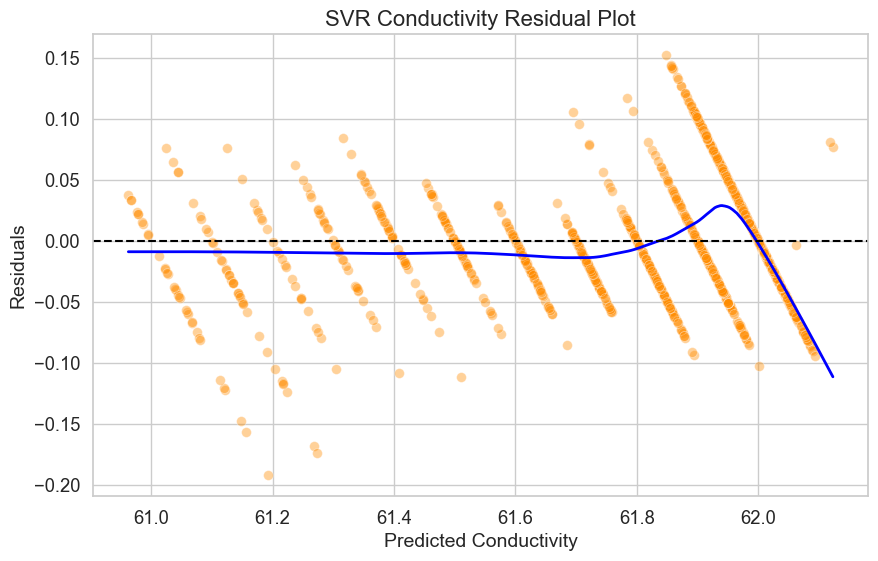

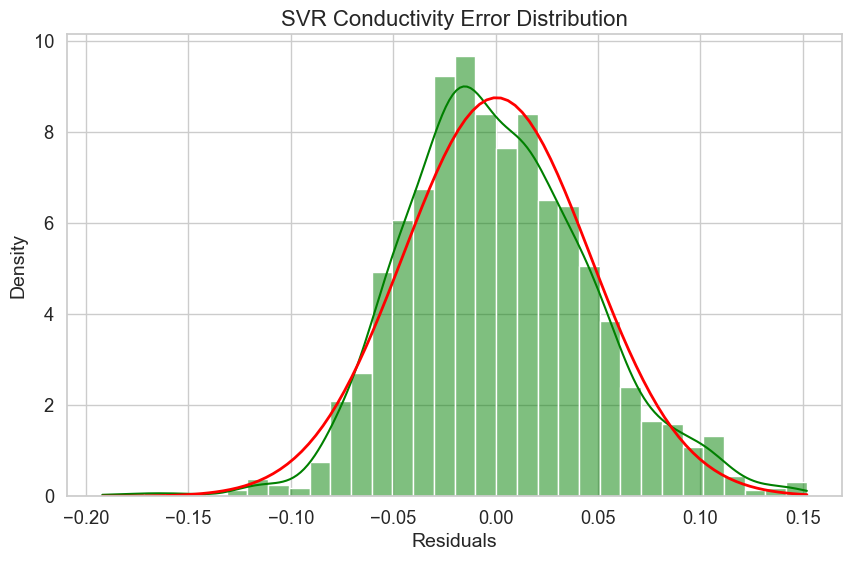

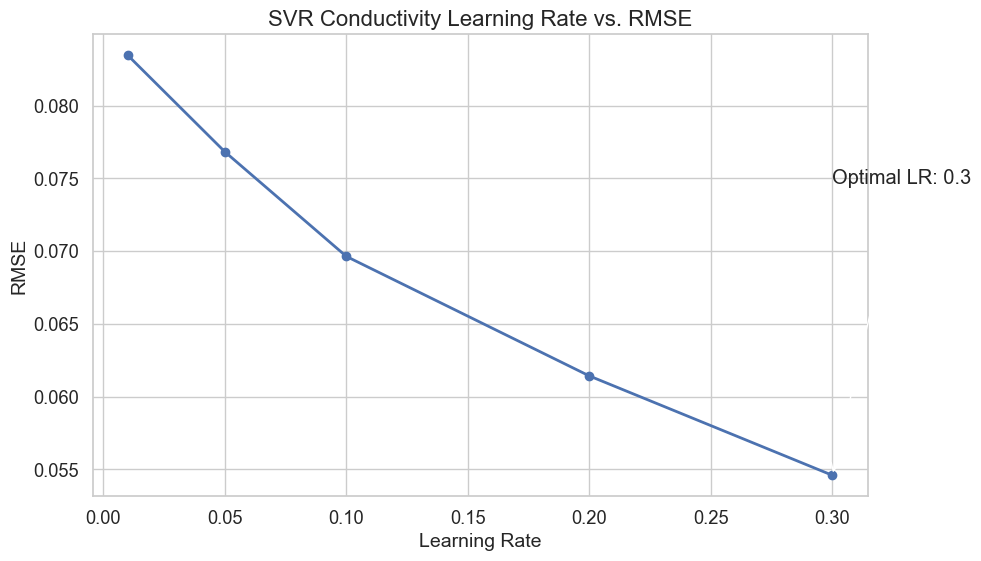

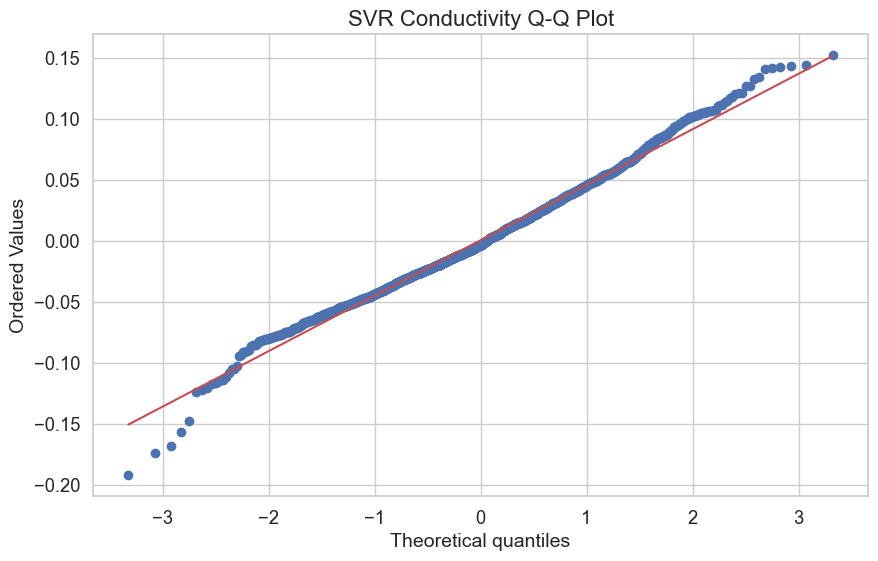

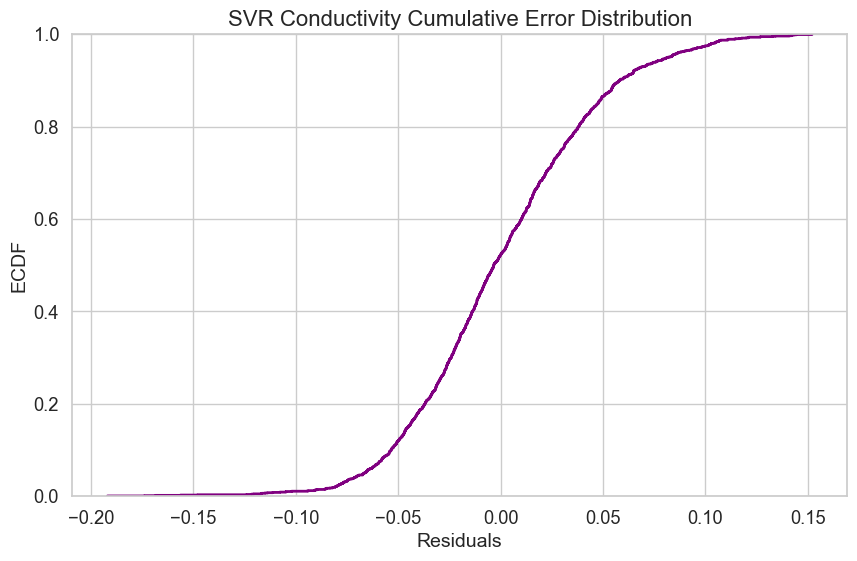

In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Load dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# Data cleaning
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

# Data preparation
columns_to_exclude = ["elongation", "UTS", "Grade", "Grade_encoded"]
X = df.drop(columns=columns_to_exclude, errors="ignore")
y = df["Conductivity"]  # Changed to predict Conductivity

# Feature scaling
scaler = MinMaxScaler()
X[X.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(X.select_dtypes(include=["float64", "int64"]))

# Encode categorical variables
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# Train / Validation / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Define SVR model with RBF kernel
svr_model = SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale")
svr_model.fit(X_train, y_train)

# Predict on test set
y_test_pred = svr_model.predict(X_test)

# Compute Evaluation Metrics
r2_test = r2_score(y_test, y_test_pred)
rmse = mean_squared_error(y_test, y_test_pred, squared=False)
mae = mean_absolute_error(y_test, y_test_pred)
mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

# Print results in requested format (excluding Median Absolute Error)
print("\n🔹 SVR for Conductivity")
print(f"✅ R² Score: {r2_test:.4f}")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f} ")
print(f"✅ MAPE: {mape:.2f}% ")

# Residuals
residuals = y_test - y_test_pred

# Visualizations
output_dir = "SVR_conductivity_plots"
os.makedirs(output_dir, exist_ok=True)

# Enhanced global styling
sns.set(style="whitegrid", font_scale=1.2, rc={"font.family": "Arial", "axes.titlesize": 16, "axes.labelsize": 14})

# High-quality DPI
dpi = 400

# 1. SVR Conductivity Actual vs. Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.4, color="royalblue", s=50)
sns.regplot(x=y_test, y=y_test_pred, scatter=False, color="red", lowess=True, line_kws={'linewidth':2})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.title("SVR Conductivity Actual vs. Predicted")
plt.xlabel("Actual Conductivity")
plt.ylabel("Predicted Conductivity")
plt.savefig(f"{output_dir}/SVR_Conductivity_Actual_vs_Predicted.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 2. SVR Conductivity Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.4, color="darkorange", s=50)
sns.regplot(x=y_test_pred, y=residuals, scatter=False, color="blue", lowess=True, line_kws={'linewidth':2})
plt.axhline(0, color="black", linestyle='--')
plt.title("SVR Conductivity Residual Plot")
plt.xlabel("Predicted Conductivity")
plt.ylabel("Residuals")
plt.savefig(f"{output_dir}/SVR_Conductivity_Residual_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 3. SVR Conductivity Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color="green", stat="density")
x_vals = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x_vals, stats.norm.pdf(x_vals, residuals.mean(), residuals.std()), color="red", linewidth=2)
plt.title("SVR Conductivity Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.savefig(f"{output_dir}/SVR_Conductivity_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 4. SVR Conductivity Learning Curves
# Justification: SVR does not have an iterative training process like tree-based models (e.g., XGBoost).
# Therefore, it doesn't support learning curves as training is not done in incremental steps.
# We are removing this plot as it wouldn't be meaningful for SVR.

# 5. SVR Conductivity Hyperparameter vs. Error Plot (learning rate tuning example)
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
errors = []
for lr in learning_rates:
    svr_model_temp = SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma=lr)
    svr_model_temp.fit(X_train, y_train)
    y_pred_temp = svr_model_temp.predict(X_test)
    rmse_temp = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    errors.append(rmse_temp)

plt.figure(figsize=(10, 6))
plt.plot(learning_rates, errors, marker='o', linewidth=2)
best_lr = learning_rates[np.argmin(errors)]
plt.annotate(f'Optimal LR: {best_lr}', xy=(best_lr, min(errors)), xytext=(best_lr, min(errors)+0.02),
             arrowprops=dict(facecolor='black', arrowstyle='->'))
plt.title("SVR Conductivity Learning Rate vs. RMSE")
plt.xlabel("Learning Rate")
plt.ylabel("RMSE")
plt.savefig(f"{output_dir}/SVR_Conductivity_Hyperparameter_vs_Error.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 6. SVR Conductivity Feature Importance
# Justification: SVR (with non-linear kernels) does not provide direct feature importance like tree-based models (e.g., XGBoost or Random Forest).
# Therefore, we will not plot the feature importance for SVR. However, Permutation Importance can be used if needed.
# For this example, we'll skip this plot.

# 7. SVR Conductivity SHAP Summary Plot
# Justification: SVR doesn't support SHAP directly, and since we're using a non-linear kernel, interpreting it through SHAP isn't straightforward.
# Therefore, we'll skip this plot as well.

# 8. SVR Conductivity Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("SVR Conductivity Q-Q Plot")
plt.savefig(f"{output_dir}/SVR_Conductivity_QQ_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 9. SVR Conductivity Cumulative Error Distribution
plt.figure(figsize=(10, 6))
sns.ecdfplot(residuals, color="purple", linewidth=2)
plt.title("SVR Conductivity Cumulative Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("ECDF")
plt.savefig(f"{output_dir}/SVR_Conductivity_Cumulative_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()